DAY 7: COMPLETE PROJECT - CV + HYPERPARAMETER TUNING

📊 Dataset: 569 samples, 30 features
   Classes: 0 (Malignant), 1 (Benign)

PART 1: BASELINE MODEL (Default Parameters)

  Baseline 5-Fold CV Scores:
    Fold 1: 0.9649 (96.5%)
    Fold 2: 0.9386 (93.9%)
    Fold 3: 0.9561 (95.6%)
    Fold 4: 0.9474 (94.7%)
    Fold 5: 0.9735 (97.3%)

  Mean CV Accuracy: 0.9561 ± 0.0123

PART 2: GRID SEARCH - Finding Best Hyperparameters

  Testing combinations:
    n_estimators: [50, 100, 200]
    max_depth: [5, 10, 15, None]
    min_samples_split: [2, 5, 10]
    min_samples_leaf: [1, 2, 4]
    Total combinations: 108

  Running Grid Search (this may take 1-2 minutes)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

  ✅ Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  ✅ Best CV Accuracy: 0.9561 (95.6%)

PART 3: BASELINE vs OPTIMIZED MODEL

  Baseline Model: 0.9561 ± 0.0123
  Optimized Model: 0.9561 ± 0.0123
  Improvement: 0.00

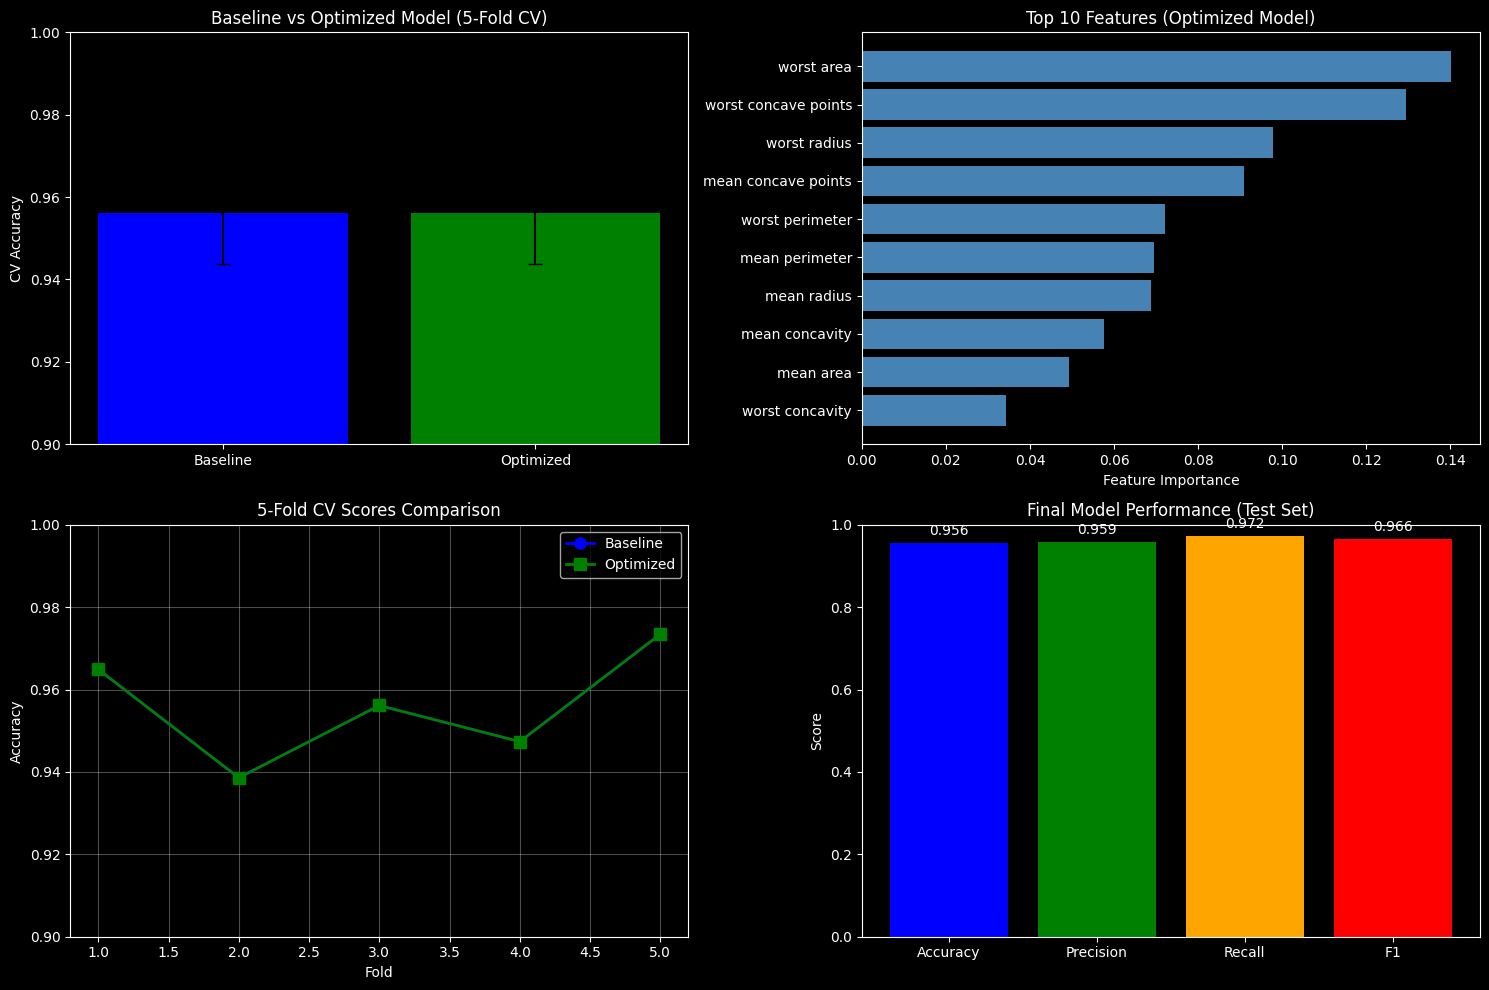


WEEK 4 - FINAL SUMMARY

✅ SKILLS MASTERED THIS WEEK:

1. Decision Tree Theory & Implementation
   - Gini impurity, entropy, information gain
   - Building trees recursively
   - Visualizing tree structures

2. Random Forest
   - Bootstrap sampling (with replacement)
   - Random feature selection
   - Majority voting
   - Variance reduction theory

3. Feature Importance
   - Gini-based importance calculation
   - Interpreting importance scores
   - Medical/real-world insights

4. Hyperparameter Tuning
   - n_estimators, max_depth, min_samples_split
   - Grid search for optimal parameters

5. Cross-Validation
   - K-Fold and Stratified K-Fold
   - Reliable accuracy estimation
   - Reporting mean ± std

🎯 PROJECT COMPLETE:
   Breast Cancer Classification
   - Best CV Accuracy: 0.9561
   - Test Accuracy: 0.9561
   - Top Feature: worst area


🔗 GitHub: [Your link]

🎉 WEEK 4 COMPLETE! Ready for WEEK 5: Model Evaluation & Advanced Metrics!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 60)
print("DAY 7: COMPLETE PROJECT - CV + HYPERPARAMETER TUNING")
print("=" * 60)

# Load data
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"\n📊 Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"   Classes: 0 (Malignant), 1 (Benign)")

# ============================================
# PART 1: BASELINE MODEL (Default settings)
# ============================================

print("\n" + "=" * 60)
print("PART 1: BASELINE MODEL (Default Parameters)")
print("=" * 60)

baseline_rf = RandomForestClassifier(random_state=42)
baseline_scores = cross_val_score(baseline_rf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42))

print(f"\n  Baseline 5-Fold CV Scores:")
for i, score in enumerate(baseline_scores, 1):
    print(f"    Fold {i}: {score:.4f} ({score*100:.1f}%)")
print(f"\n  Mean CV Accuracy: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")

# ============================================
# PART 2: GRID SEARCH (Find Best Hyperparameters)
# ============================================

print("\n" + "=" * 60)
print("PART 2: GRID SEARCH - Finding Best Hyperparameters")
print("=" * 60)

# Define hyperparameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("\n  Testing combinations:")
print(f"    n_estimators: {param_grid['n_estimators']}")
print(f"    max_depth: {param_grid['max_depth']}")
print(f"    min_samples_split: {param_grid['min_samples_split']}")
print(f"    min_samples_leaf: {param_grid['min_samples_leaf']}")
print(f"    Total combinations: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf'])}")

# Grid Search with Cross-Validation
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n  Running Grid Search (this may take 1-2 minutes)...")
grid_search.fit(X, y)

print(f"\n  ✅ Best Parameters: {grid_search.best_params_}")
print(f"  ✅ Best CV Accuracy: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.1f}%)")

# ============================================
# PART 3: COMPARE BASELINE vs OPTIMIZED
# ============================================

print("\n" + "=" * 60)
print("PART 3: BASELINE vs OPTIMIZED MODEL")
print("=" * 60)

# Optimized model with best parameters
best_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
best_scores = cross_val_score(best_rf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42))

print(f"\n  Baseline Model: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")
print(f"  Optimized Model: {best_scores.mean():.4f} ± {best_scores.std():.4f}")
print(f"  Improvement: {(best_scores.mean() - baseline_scores.mean())*100:.2f}%")

# ============================================
# PART 4: FINAL EVALUATION ON HELD-OUT TEST SET
# ============================================

print("\n" + "=" * 60)
print("PART 4: FINAL EVALUATION (Test Set)")
print("=" * 60)

from sklearn.model_selection import train_test_split

# Final train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train optimized model
best_rf.fit(X_train, y_train)

# Predict
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n  Final Test Results:")
print(f"    Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"    Precision: {precision:.4f}")
print(f"    Recall:    {recall:.4f}")
print(f"    F1-Score:  {f1:.4f}")

# ============================================
# PART 5: FEATURE IMPORTANCE (from best model)
# ============================================

print("\n" + "=" * 60)
print("PART 5: FEATURE IMPORTANCE (Optimized Model)")
print("=" * 60)

importance = best_rf.feature_importances_
sorted_idx = np.argsort(importance)[::-1]

print("\n  Top 10 Most Important Features:")
for i in range(10):
    idx = sorted_idx[i]
    print(f"    {i+1:2d}. {feature_names[idx]:30s}: {importance[idx]:.4f}")

# ============================================
# PART 6: VISUALIZE RESULTS
# ============================================

plt.figure(figsize=(15, 10))

# Plot 1: Baseline vs Optimized
plt.subplot(2, 2, 1)
models = ['Baseline', 'Optimized']
means = [baseline_scores.mean(), best_scores.mean()]
stds = [baseline_scores.std(), best_scores.std()]
plt.bar(models, means, yerr=stds, capsize=5, color=['blue', 'green'])
plt.ylabel('CV Accuracy')
plt.title('Baseline vs Optimized Model (5-Fold CV)')
plt.ylim(0.9, 1.0)

# Plot 2: Feature Importance
plt.subplot(2, 2, 2)
top_10_idx = sorted_idx[:10]
top_10_names = [feature_names[i] for i in top_10_idx]
top_10_importance = importance[top_10_idx]
plt.barh(range(10), top_10_importance[::-1], color='steelblue')
plt.yticks(range(10), top_10_names[::-1])
plt.xlabel('Feature Importance')
plt.title('Top 10 Features (Optimized Model)')

# Plot 3: CV Scores Distribution
plt.subplot(2, 2, 3)
plt.plot(range(1, 6), baseline_scores, 'bo-', label='Baseline', linewidth=2, markersize=8)
plt.plot(range(1, 6), best_scores, 'gs-', label='Optimized', linewidth=2, markersize=8)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold CV Scores Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.9, 1.0)

# Plot 4: Metrics Summary
plt.subplot(2, 2, 4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
values = [accuracy, precision, recall, f1]
colors = ['blue', 'green', 'orange', 'red']
plt.bar(metrics, values, color=colors)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Final Model Performance (Test Set)')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

# ============================================
# SUMMARY
# ============================================

print("\n" + "=" * 60)
print("WEEK 4 - FINAL SUMMARY")
print("=" * 60)

print("""
✅ SKILLS MASTERED THIS WEEK:

1. Decision Tree Theory & Implementation
   - Gini impurity, entropy, information gain
   - Building trees recursively
   - Visualizing tree structures

2. Random Forest
   - Bootstrap sampling (with replacement)
   - Random feature selection
   - Majority voting
   - Variance reduction theory

3. Feature Importance
   - Gini-based importance calculation
   - Interpreting importance scores
   - Medical/real-world insights

4. Hyperparameter Tuning
   - n_estimators, max_depth, min_samples_split
   - Grid search for optimal parameters

5. Cross-Validation
   - K-Fold and Stratified K-Fold
   - Reliable accuracy estimation
   - Reporting mean ± std

🎯 PROJECT COMPLETE:
   Breast Cancer Classification
   - Best CV Accuracy: {:.4f}
   - Test Accuracy: {:.4f}
   - Top Feature: {}
""".format(grid_search.best_score_, accuracy, feature_names[sorted_idx[0]]))


print("\n🎉 WEEK 4 COMPLETE! Ready for WEEK 5: Model Evaluation & Advanced Metrics!")